# **TOÁN ỨNG DỤNG VÀ THỐNG KÊ**

# **Đồ án thực hành cuối kỳ**

## **Mục lục**

* [**Thông tin sinh viên**](#c1)
* [**Mô tả bài toán và giải thuậ**t](#c2)

* [**Bài 1. Dự đoán giá nhà tại Stockton**](#c3)
* [Câu a: Khám phá dữ liệu](#c4)
* [Câu b: Xây dựng mô hình hồi quy đơn biến](#c5)
* [Câu c: Xây dựng mô hình hồi quy đa biến](#c6)
* [Câu d: Biến đổi dữ liệu để cải thiện mô hình và đánh giá chọn mô hình tốt nhất](#c7)

* [**Bài 2: Xích Markov dự đoán giao thông**](#c8)
* [Câu a: Tạo dữ liệu mô phỏng](#c9)
* [Câu b: Ma trận đếm số lần chuyển trạng thái](#c10)
* [Câu c: Ma trận xác suất chuyển](#11)
* [Câu d: Dự đoán trạng thái sau k ngày](#12)
* [Câu e: Tìm phân phối dừng](#13)
* [**Mô tả ý tưởng thực hiện**](#14)
* [**Mô tả các hàm**](#15)

# =============================================================================
# **PHẦN THÔNG TIN SINH VIÊN** <a id="c1"></a>
# =============================================================================

## **Họ và tên:** Nguyễn Hải Đăng

## **Mã số sinh viên:** 23127165

## **Lớp:** 23CLC03

# =============================================================================
# **PHẦN MÔ TẢ BÀI TOÁN VÀ GIẢI THUẬT** <a id="c2"></a>
# =============================================================================

## **Bài toán 1: Dự đoán giá nhà tại Stockton, California**

*   **Mục tiêu:** Xây dựng mô hình hồi quy để dự đoán giá bán nhà (`sprice`) dựa trên các đặc trưng có sẵn như diện tích (`livarea`), số phòng ngủ (`beds`), số phòng tắm (`baths`), diện tích lô đất lớn (`lgelot`), tuổi của ngôi nhà (`age`), và có hồ bơi hay không (`pool`).
*   **Phương pháp giải:**
    1.  **Khám phá dữ liệu:** Đọc và phân tích dữ liệu, tính toán các đại lượng thống kê mô tả, và xem xét mối tương quan giữa giá nhà và các đặc trưng khác thông qua biểu đồ.
    2.  **Mô hình đơn biến:** Xây dựng các mô hình hồi quy tuyến tính đơn giản (một biến độc lập) cho từng đặc trưng. Đánh giá mỗi mô hình dựa trên "độ lớn vector phần dư" để tìm ra đặc trưng có sức mạnh dự đoán tốt nhất khi đứng một mình.
    3.  **Mô hình đa biến:** Kết hợp tất cả các đặc trưng vào một mô hình hồi quy tuyến tính đa biến. Mô hình này được giải bằng phương pháp đại số tuyến tính (sử dụng ma trận).
    4.  **Cải thiện mô hình:** Thử nghiệm các phép biến đổi đặc trưng (như lấy log, lấy bình phương) để xem liệu mô hình có thể nắm bắt được các mối quan hệ phi tuyến tính và cho kết quả tốt hơn không.
    5.  **Đánh giá:** So sánh tất cả các mô hình dựa trên chỉ số lỗi và trực quan hóa kết quả để đưa ra kết luận cuối cùng.

## **Bài toán 2: Xích Markov trong dự đoán giao thông**


*   **Mục tiêu:** Sử dụng Xích Markov để mô hình hóa và dự đoán tình trạng giao thông. Cụ thể là xây dựng ma trận xác suất chuyển trạng thái và dùng nó để dự đoán phân phối xác suất của các trạng thái giao thông trong tương lai.
*   **Phương pháp giải:**
    1.  **Mô phỏng dữ liệu:** Tạo ra chuỗi 60 ngày theo yêu cầu.
    2.  **Xây dựng ma trận đếm:** Đếm số lần chuyển từ trạng thái này sang trạng thái khác từ chuỗi dữ liệu đã tạo.
    3.  **Tính ma trận xác suất chuyển:** Chuẩn hóa ma trận đếm theo từng hàng để có được ma trận xác suất chuyển.
    4.  **Dự đoán tương lai:** Viết hàm `prop_distribution(k)` để tính phân phối xác suất của các trạng thái sau `k` ngày, dựa trên phép nhân ma trận.
    5.  **Tìm phân phối dừng:** Viết hàm `prop_sta()` để tìm phân phối xác suất ổn định của hệ thống trong dài hạn.


# =============================================================================
# **PHẦN GIẢI BÀI** <a id="c3"></a>
# =============================================================================

## **Bài 1. Dự đoán giá nhà tại Stockton**  <a id="c3"></a>

In [38]:
import pandas as pd # chỉ dùng để đọc file CSV
import math
import matplotlib.pyplot as plt               # chỉ dùng để vẽ biểu đồ
from IPython.display import display, Math     # chỉ dùng để hiển thị công thức toán học cho đẹp
from google.colab import drive                # chỉ dùng để hạy trên google collab

try:
    # Nếu đang chạy trong Google Colab thì sẽ có module 'google.colab'
    from google.colab import drive
    COLAB = True
except ImportError:
    COLAB = False

if COLAB:
    # Mount Google Drive
    drive.mount("/content/drive", force_remount=True)
    csv_path = "/content/drive/MyDrive/Colab Notebooks/stockton4.csv"
    # csv_path = "/content/drive/MyDrive/.../stocktaon4.csv" # đổi theo tên (các) thư mục của bạn
else:
    # Trên máy cá nhân, giả sử file CSV nằm cùng thư mục code
    csv_path = "stockton4.csv"

# Đọc dữ liệu
df = pd.read_csv(csv_path)
header = df.columns.tolist()
data = df.values.tolist()

# -----------------------------------------------------------------------------
# NHÓM 1: CÁC HÀM XỬ LÝ DỮ LIỆU VÀ THỐNG KÊ
# -----------------------------------------------------------------------------

# Hàm tính toán các thống kê cơ bản
def calculate_stats(data_list):
    """
    Tính mean, std, min, max của một danh sách
    """
    n = len(data_list)
    mean = sum(data_list) / n

    variance = sum((x - mean) ** 2 for x in data_list) / (n - 1)
    std = math.sqrt(variance)

    return {
        'mean': mean,
        'std': std,
        'min': min(data_list),
        'max': max(data_list),
        'count': n
    }

# Hàm tính correlation coefficient
def correlation(x, y):
    """
    Tính hệ số tương quan Pearson giữa x và y
    """
    n = len(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_x2 = sum(xi**2 for xi in x)
    sum_y2 = sum(yi**2 for yi in y)
    sum_xy = sum(x[i] * y[i] for i in range(n))

    numerator = n * sum_xy - sum_x * sum_y
    denominator = math.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))

    if denominator == 0:
        return 0
    return numerator / denominator

# -----------------------------------------------------------------------------
# NHÓM 2: CÁC HÀM HỒI QUY TUYẾN TÍNH
# -----------------------------------------------------------------------------

# Hàm hồi quy tuyến tính đơn biến
def simple_linear_regression(x, y):
    """
    Thực hiện hồi quy tuyến tính đơn biến: y = a + b*x
    Trả về a (intercept), b (slope), và các chỉ số đánh giá
    """
    n = len(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xy = sum(x[i] * y[i] for i in range(n))
    sum_x2 = sum(xi**2 for xi in x)

    # Tính hệ số
    b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    a = (sum_y - b * sum_x) / n

    # Dự đoán
    y_pred = [a + b * xi for xi in x]

    # Tính residuals
    residuals = [y[i] - y_pred[i] for i in range(n)]

    # Tính độ lớn vector phần dư (RSS - Residual Sum of Squares)
    rss = sum(r**2 for r in residuals)
    residual_magnitude = math.sqrt(rss)

    # Tính R-squared
    y_mean = sum(y) / n
    tss = sum((yi - y_mean)**2 for yi in y)  # Total Sum of Squares
    r_squared = 1 - (rss / tss) if tss != 0 else 0

    # Tính RMSE
    rmse = math.sqrt(rss / n) if n > 0 else 0

    return {
        'intercept': a,
        'slope': b,
        'predictions': y_pred,
        'residuals': residuals,
        'rss': rss,
        'residual_magnitude': residual_magnitude,
        'r_squared': r_squared,
        'rmse': rmse
    }

# Hàm hồi quy tuyến tính đa biến (sử dụng phương pháp ma trận)
def multiple_linear_regression(X, y):
    """
    Thực hiện hồi quy tuyến tính đa biến: y = b0 + b1*x1 + b2*x2 + ... + bn*xn
    X là ma trận các biến độc lập (đã bao gồm cột 1 cho intercept)
    y là vector biến phụ thuộc
    """
    # Tính (X^T * X)
    n_rows = len(X)
    n_cols = len(X[0])

    # X transpose
    XT = [[X[i][j] for i in range(n_rows)] for j in range(n_cols)]

    # XT * X
    XTX = [[0] * n_cols for _ in range(n_cols)]
    for i in range(n_cols):
        for j in range(n_cols):
            XTX[i][j] = sum(XT[i][k] * X[k][j] for k in range(n_rows))

    # XT * y
    XTy = [sum(XT[i][k] * y[k] for k in range(n_rows)) for i in range(n_cols)]

    # Giải hệ phương trình XTX * beta = XTy bằng Gaussian elimination
    beta = gaussian_elimination(XTX, XTy)

    # Dự đoán
    y_pred = [sum(X[i][j] * beta[j] for j in range(n_cols)) for i in range(n_rows)]

    # Tính residuals
    residuals = [y[i] - y_pred[i] for i in range(n_rows)]

    # Tính độ lớn vector phần dư (RSS - Residual Sum of Squares)
    rss = sum(r**2 for r in residuals)
    residual_magnitude = math.sqrt(rss)

    # Tính R-squared
    y_mean = sum(y) / len(y)
    tss = sum((yi - y_mean)**2 for yi in y)
    r_squared = 1 - (rss / tss) if tss != 0 else 0

    # Tính RMSE
    rmse = math.sqrt(rss / n_rows) if n_rows > 0 else 0

    return {
        'coefficients': beta,
        'predictions': y_pred,
        'residuals': residuals,
        'rss': rss,
        'residual_magnitude': residual_magnitude,
        'r_squared': r_squared,
        'rmse': rmse
    }

# Hàm giải hệ phương trình tuyến tính bằng Gaussian elimination
def gaussian_elimination(A, b):
    """
    Giải hệ phương trình Ax = b bằng phương pháp Gaussian elimination
    """
    n = len(A)
    # Tạo ma trận mở rộng
    augmented = [A[i][:] + [b[i]] for i in range(n)]

    # Forward elimination
    for i in range(n):
        # Tìm pivot
        max_row = i
        for k in range(i + 1, n):
            if abs(augmented[k][i]) > abs(augmented[max_row][i]):
                max_row = k

        # Hoán đổi hàng
        augmented[i], augmented[max_row] = augmented[max_row], augmented[i]

        # Khử
        for k in range(i + 1, n):
            if augmented[i][i] != 0:
                factor = augmented[k][i] / augmented[i][i]
                for j in range(i, n + 1):
                    augmented[k][j] -= factor * augmented[i][j]

    # Back substitution
    x = [0] * n
    for i in range(n - 1, -1, -1):
        x[i] = augmented[i][n]
        for j in range(i + 1, n):
            x[i] -= augmented[i][j] * x[j]
        if augmented[i][i] != 0:
            x[i] /= augmented[i][i]

    return x

# -----------------------------------------------------------------------------
# NHÓM 3: CÁC HÀM TRỰC QUAN HÓA
# -----------------------------------------------------------------------------

# Vẽ scatter plot (giá nhà vs 1 biến)
def plot_scatter(x, y, y_pred=None, xlabel="X", ylabel="sprice", title="Scatter Plot"):
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, alpha=0.5, label="Thực tế")
    if y_pred is not None:
        plt.plot(x, y_pred, color="red", label="Dự đoán")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

# Vẽ boxplot (cho biến nhị phân)
def plot_boxplot(x, y, xlabel="Category", ylabel="sprice", title="Boxplot"):
    categories = sorted(set(x))
    data = [[y[i] for i in range(len(x)) if x[i] == c] for c in categories]
    plt.figure(figsize=(6,4))
    plt.boxplot(data, tick_labels=categories)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# Vẽ heatmap ma trận tương quan (tự code tay)
def plot_correlation_matrix(data_dict):
    keys = list(data_dict.keys())
    n = len(keys)
    # Tạo ma trận rỗng
    corr_matrix = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        for j in range(n):
            corr_matrix[i][j] = correlation(data_dict[keys[i]], data_dict[keys[j]])

    plt.figure(figsize=(7,6))
    plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(n), keys, rotation=45)
    plt.yticks(range(n), keys)
    plt.title("Correlation Matrix")
    # Ghi số lên ma trận
    for i in range(n):
        for j in range(n):
            plt.text(j, i, f"{corr_matrix[i][j]:.2f}", ha="center", va="center", color="black")
    plt.show()

# Vẽ thực tế vs dự đoán
def plot_actual_vs_pred(y, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(6,4))
    plt.scatter(y, y_pred, alpha=0.5)
    min_val, max_val = min(y), max(y)
    plt.plot([min_val, max_val], [min_val, max_val], "r--")
    plt.xlabel("Thực tế")
    plt.ylabel("Dự đoán")
    plt.title(title)
    plt.show()

# Tách các cột
sprice = [row[0] for row in data]
livarea = [row[1] for row in data]
beds    = [row[2] for row in data]
baths   = [row[3] for row in data]
lgelot  = [row[4] for row in data]
age     = [row[5] for row in data]
pool    = [row[6] for row in data]

Mounted at /content/drive


### **a) Khám phá dữ liệu** <a id="c4"></a>

* Đọc dữ liệu từ file `stockton4.csv`.
* Tính toán thống kê mô tả cho từng biến: số lượng quan sát, trung bình, độ lệch chuẩn, min, max.
* Vẽ các biểu đồ:

  * Scatter plot giữa `sprice` và `livarea`, `beds`, `baths`, `age`.
  * Boxplot cho `lgelot` và `pool`.
  * Ma trận tương quan giữa tất cả các biến.
* **Nhận xét sơ bộ:** phân tích xem biến nào có quan hệ tuyến tính mạnh nhất với giá nhà, biến nào ít ảnh hưởng.


Câu a) KHÁM PHÁ DỮ LIỆU
sprice  : Mean = 123693.85133333334; Std = 63250.88976211874; Min = 22000.0; Max = 713000.0
livarea : Mean = 16.746666666666666; Std = 5.461963406296619; Min = 7.0; Max = 49.0
beds    : Mean = 3.2853333333333334; Std = 0.619817988160923; Min = 1.0; Max = 6.0
baths   : Mean = 2.133; Std = 0.5253522595977321; Min = 1.0; Max = 6.5
lgelot  : Mean = 0.06333333333333334; Std = 0.24364276462351833; Min = 0.0; Max = 1.0
age     : Mean = 21.86; Std = 13.114637972615505; Min = 0.0; Max = 97.0
pool    : Mean = 0.06533333333333333; Std = 0.24719552174922343; Min = 0.0; Max = 1.0

Tương quan với giá nhà (sprice):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Vẽ các biểu đồ khám phá dữ liệu:


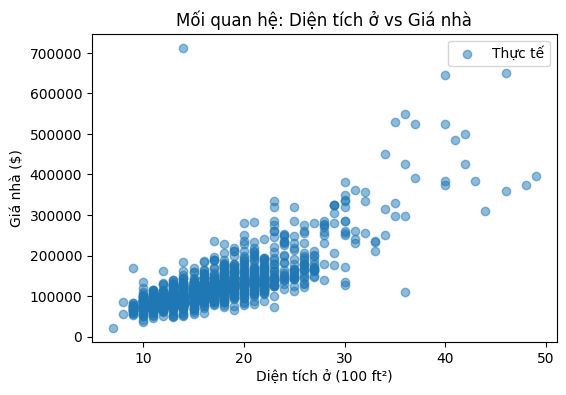

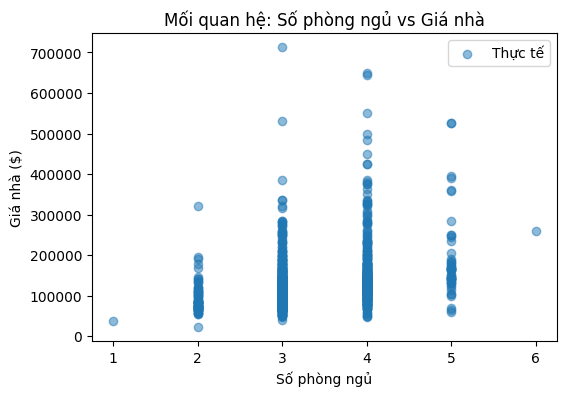

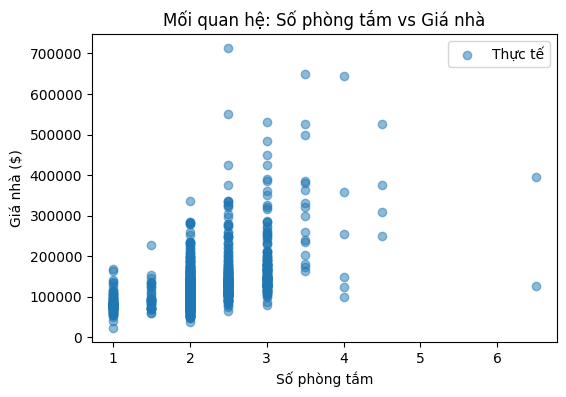

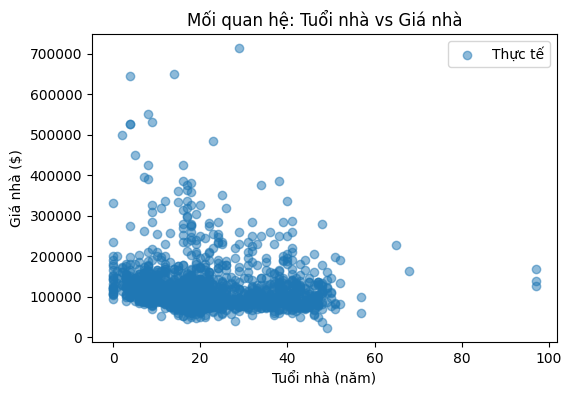

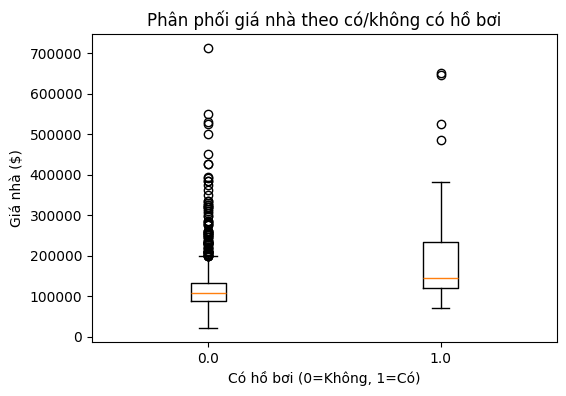

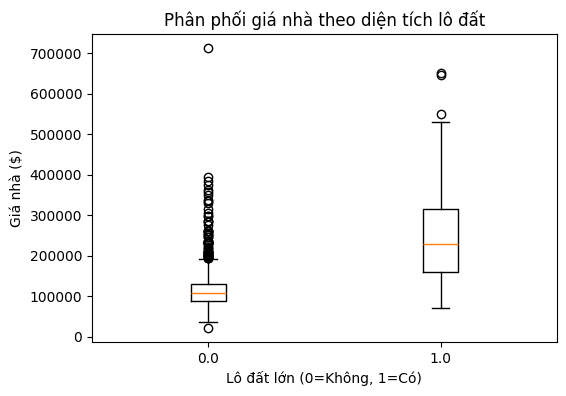

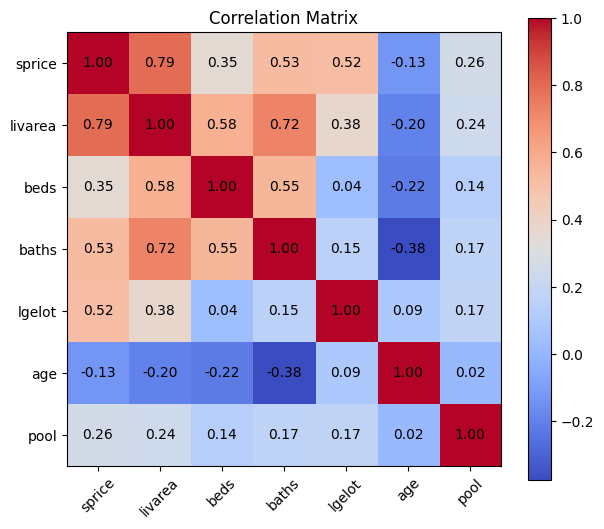

In [39]:
print("\n" + "=" * 60)
print("Câu a) KHÁM PHÁ DỮ LIỆU")
print("=" * 60)

# Thống kê mô tả cho giá nhà
variables = {
    'sprice': sprice, 'livarea': livarea, 'beds': beds,
    'baths': baths, 'lgelot': lgelot, 'age': age, 'pool': pool
}

for name, var in variables.items():
    stats = calculate_stats(var)
    print(f"{name:8}: Mean = {stats['mean']:}; Std = {stats['std']:}; "
          f"Min = {stats['min']:}; Max = {stats['max']:}")

# Hệ số tương quan giữa các biến và sprice
print("\nTương quan với giá nhà (sprice):")
correlations = {
    'livarea': correlation(livarea, sprice),
    'beds': correlation(beds, sprice),
    'baths': correlation(baths, sprice),
    'lgelot': correlation(lgelot, sprice),
    'age': correlation(age, sprice),
    'pool': correlation(pool, sprice)
}
for var, corr in correlations.items():
    display(Math(f"r_{{sprice,{var}}} = {corr:}"))

# Vẽ biểu đồ
print("\nVẽ các biểu đồ khám phá dữ liệu:")

# Scatter plots cho biến liên tục
plot_scatter(livarea, sprice, xlabel="Diện tích ở (100 ft²)", ylabel="Giá nhà ($)", title="Mối quan hệ: Diện tích ở vs Giá nhà")
plot_scatter(beds, sprice, xlabel="Số phòng ngủ", ylabel="Giá nhà ($)", title="Mối quan hệ: Số phòng ngủ vs Giá nhà")
plot_scatter(baths, sprice, xlabel="Số phòng tắm", ylabel="Giá nhà ($)", title="Mối quan hệ: Số phòng tắm vs Giá nhà")
plot_scatter(age, sprice, xlabel="Tuổi nhà (năm)", ylabel="Giá nhà ($)", title="Mối quan hệ: Tuổi nhà vs Giá nhà")

# Boxplots cho biến nhị phân
plot_boxplot(pool, sprice, xlabel="Có hồ bơi (0=Không, 1=Có)", ylabel="Giá nhà ($)", title="Phân phối giá nhà theo có/không có hồ bơi")
plot_boxplot(lgelot, sprice, xlabel="Lô đất lớn (0=Không, 1=Có)", ylabel="Giá nhà ($)", title="Phân phối giá nhà theo diện tích lô đất")

# Ma trận tương quan
plot_correlation_matrix(variables)


### **b) Xây dựng hình hồi quy đơn biến** <a id="c5"></a>

* Với mỗi đặc trưng (`livarea`, `beds`, `baths`, `lgelot`, `age`, `pool`):

  1. Tính hệ số hồi quy (intercept, slope).
  2. Viết phương trình hồi quy.
  3. Vẽ đường hồi quy trên scatter plot.
  4. Tính độ lớn vector phần dư (Residual norm).
  5. Tính R² để đánh giá mức độ giải thích.
* **Kết quả:** lập bảng so sánh residual norm và R² cho tất cả đặc trưng.
* **Kết luận:** chọn ra mô hình đơn biến tốt nhất.


Câu b) MÔ HÌNH HỒI QUY ĐƠN BIẾN

Kết quả hồi quy đơn biến:


Đặc trưng R²       RMSE       Res_Magnitude   Phương trình
--------------------------------------------------------------------------------
livarea    0.6287   38531      1492303         y = -30069 + 9181.71x



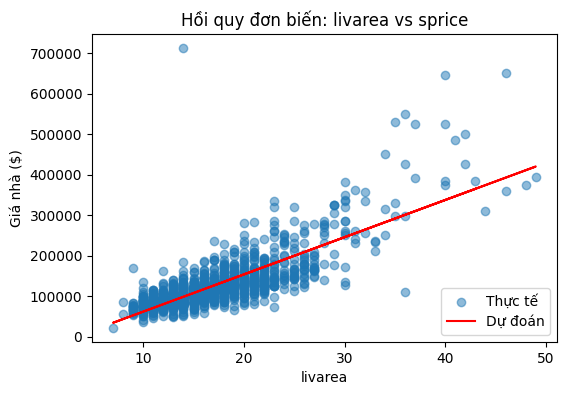



Đặc trưng R²       RMSE       Res_Magnitude   Phương trình
--------------------------------------------------------------------------------
beds       0.1203   59303      2296812         y = 7393 + 35400.03x



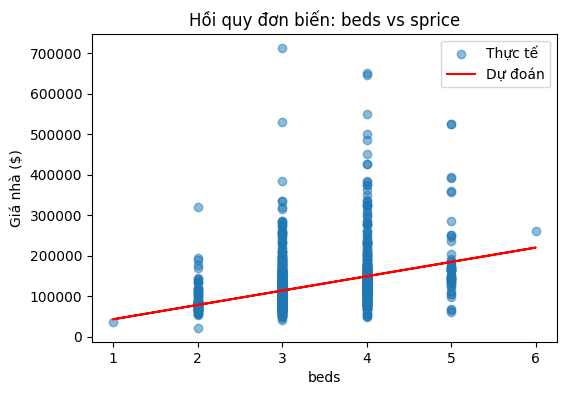



Đặc trưng R²       RMSE       Res_Magnitude   Phương trình
--------------------------------------------------------------------------------
baths      0.2774   53750      2081735         y = -11556 + 63408.22x



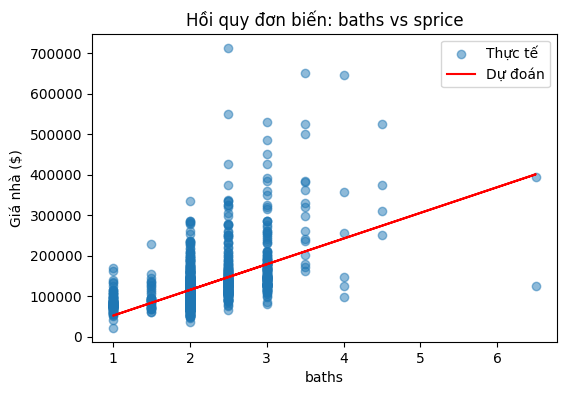



Đặc trưng R²       RMSE       Res_Magnitude   Phương trình
--------------------------------------------------------------------------------
lgelot     0.2656   54185      2098584         y = 115220 + 133797.35x



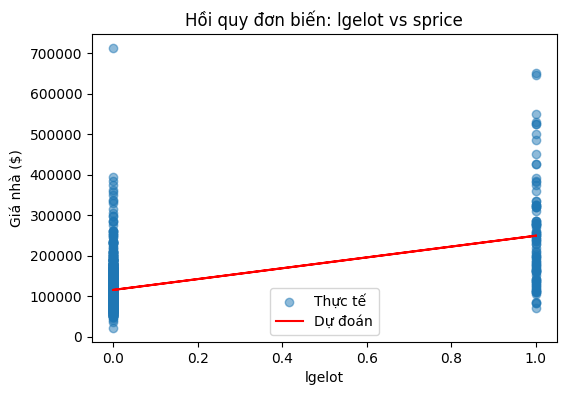



Đặc trưng R²       RMSE       Res_Magnitude   Phương trình
--------------------------------------------------------------------------------
age        0.0169   62693      2428086         y = 137404 + -627.16x



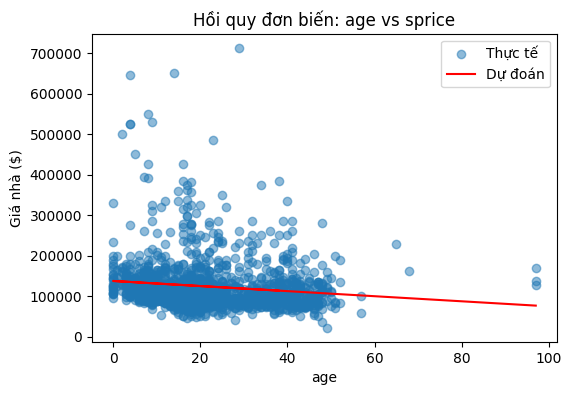



Đặc trưng R²       RMSE       Res_Magnitude   Phương trình
--------------------------------------------------------------------------------
pool       0.0685   61026      2363523         y = 119319 + 66966.70x



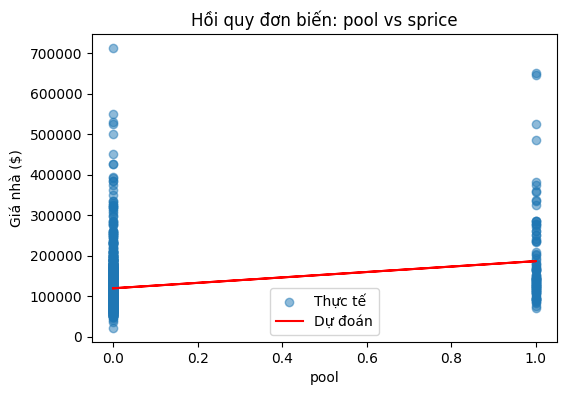


** KẾT LUẬN: Mô hình đơn biến tốt nhất là 'livarea' với:
   - Độ lớn vector phần dư: 1492302.8600311985
   - R²: 0.6286537595659704
   - RMSE: 38531.09416265687


In [40]:
print("\n" + "=" * 60)
print("Câu b) MÔ HÌNH HỒI QUY ĐƠN BIẾN")
print("=" * 60)

features = {
    'livarea': livarea,
    'beds': beds,
    'baths': baths,
    'lgelot': lgelot,
    'age': age,
    'pool': pool
}

single_models = {}
results_table = []

print("\nKết quả hồi quy đơn biến:")

for feature_name, feature_data in features.items():
    print(f"{'\n\nĐặc trưng':<10} {'R²':<8} {'RMSE':<10} {'Res_Magnitude':<15} {'Phương trình'}")
    print("-" * 80)
    model = simple_linear_regression(feature_data, sprice)
    single_models[feature_name] = model

    equation = f"y = {model['intercept']:.0f} + {model['slope']:.2f}x"
    results_table.append([feature_name, model['r_squared'], model['rmse'], model['residual_magnitude']])

    print(f"{feature_name:<10} {model['r_squared']:<8.4f} {model['rmse']:<10.0f} "
          f"{model['residual_magnitude']:<15.0f} {equation}\n")

    # Vẽ scatter + đường hồi quy
    plot_scatter(feature_data, sprice, model['predictions'],
                xlabel=feature_name, ylabel="Giá nhà ($)",
                title=f"Hồi quy đơn biến: {feature_name} vs sprice")

# Tìm mô hình đơn tốt nhất
best_single = min(single_models.items(), key=lambda x: x[1]['residual_magnitude'])
print(f"\n** KẾT LUẬN: Mô hình đơn biến tốt nhất là '{best_single[0]}' với:")
print(f"   - Độ lớn vector phần dư: {best_single[1]['residual_magnitude']:}")
print(f"   - R²: {best_single[1]['r_squared']:}")
print(f"   - RMSE: {best_single[1]['rmse']:}")

### **c) Xây dựng mô hình hồi quy đa biến** <a id="c6"></a>

* Xây dựng mô hình với tất cả các đặc trưng:

  $$
  sprice = \theta_{0} + \theta_{1}\,x_{\text{livarea}} + \theta_{2}\,x_{\text{beds}}
        + \theta_{3}\,x_{\text{baths}} + \theta_{4}\,x_{\text{lgelot}}
        + \theta_{5}\,x_{\text{age}} + \theta_{6}\,x_{\text{pool}}
  $$
* Tính hệ số $\theta$ bằng công thức ma trận.
* Viết phương trình đầy đủ.
* Vẽ biểu đồ so sánh giá trị thực tế và giá trị dự đoán.
* Tính residual norm và R².
* **Nhận xét:** so sánh với mô hình đơn biến.


Câu c) MÔ HÌNH HỒI QUY ĐA BIẾN

Phương trình hồi quy đa biến:


<IPython.core.display.Math object>


Đánh giá mô hình đa biến:
- R²: 0.6944048194327876
- RMSE: 34953.85469482014
- Độ lớn vector phần dư: 1353756.9711879233


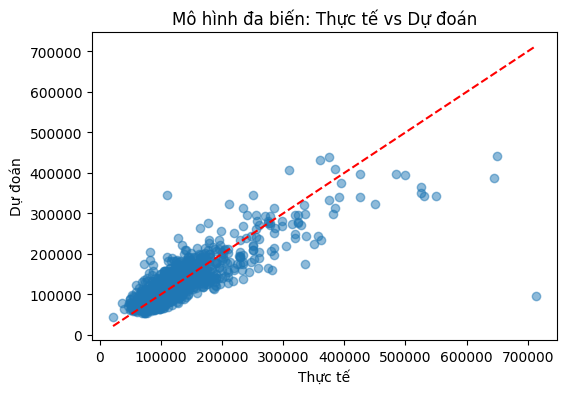


So sánh với mô hình đơn biến tốt nhất (livarea):
Mô hình         R²       RMSE       Res_Magnitude
---------------------------------------------
Đơn biến        0.6287   38531      1492303   
Đa biến         0.6944   34954      1353757   


In [41]:
print("\n" + "=" * 60)
print("Câu c) MÔ HÌNH HỒI QUY ĐA BIẾN")
print("=" * 60)

# Ma trận X (có cột 1 cho intercept)
X = [[1] + row[1:] for row in data]

multi_model = multiple_linear_regression(X, sprice)

print("\nPhương trình hồi quy đa biến:")
coef_names = ['Intercept', 'livarea', 'beds', 'baths', 'lgelot', 'age', 'pool']
equation = "y = "
for i, (name, coef) in enumerate(zip(coef_names, multi_model['coefficients'])):
    if i == 0:
        equation += f"{coef:}"
    else:
        sign = "+ " if coef >= 0 else ""
        equation += f" {sign}{coef:}x_{{{name}}}"
display(Math(equation))

print(f"\nĐánh giá mô hình đa biến:")
print(f"- R²: {multi_model['r_squared']:}")
print(f"- RMSE: {multi_model['rmse']:}")
print(f"- Độ lớn vector phần dư: {multi_model['residual_magnitude']:}")

# Vẽ thực tế vs dự đoán
plot_actual_vs_pred(sprice, multi_model['predictions'],
                   title="Mô hình đa biến: Thực tế vs Dự đoán")

# So sánh với mô hình đơn biến tốt nhất
print(f"\nSo sánh với mô hình đơn biến tốt nhất ({best_single[0]}):")
print(f"{'Mô hình':<15} {'R²':<8} {'RMSE':<10} {'Res_Magnitude'}")
print("-" * 45)
print(f"{'Đơn biến':<15} {best_single[1]['r_squared']:<8.4f} "
      f"{best_single[1]['rmse']:<10.0f} {best_single[1]['residual_magnitude']:<10.0f}")
print(f"{'Đa biến':<15} {multi_model['r_squared']:<8.4f} "
      f"{multi_model['rmse']:<10.0f} {multi_model['residual_magnitude']:<10.0f}")

### **d) Biến đổi dữ liệu để cải thiện mô hình và đánh giá chọn mô hình tốt nhất** <a id="c7"></a>

* Thử log-transform với `sprice`:

  * Xây dựng mô hình hồi quy với `log(sprice)` thay cho `sprice`.
  * So sánh residual norm và R² với mô hình cũ.
* Thử bình phương `livarea`.
* Có thể thử thêm kết hợp biến (ví dụ: `beds * baths`).
* **Kết quả:** ghi lại residual norm, R² sau khi biến đổi.
* **Kết luận:** chọn mô hình tối ưu nhất trong tất cả các mô hình.


Câu d) BIẾN ĐỔI ĐẶC TRƯNG - MÔ HÌNH ĐA DẠNG

1. Mô hình với log transformation của sprice:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

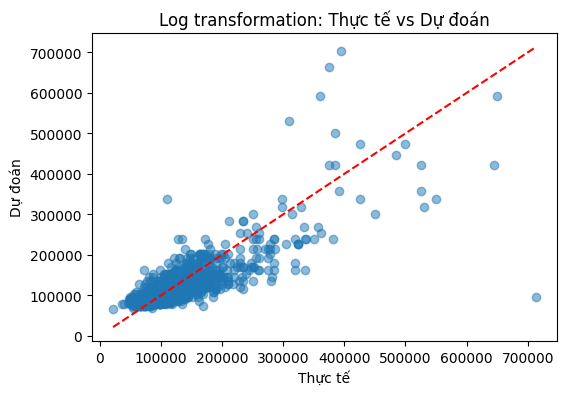


2. Mô hình polynomial với livarea:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

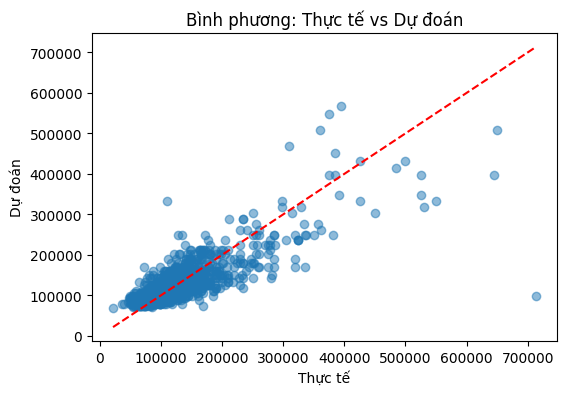

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

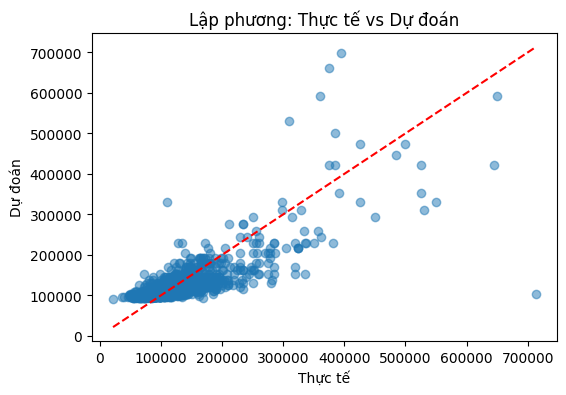


3. Mô hình căn bậc hai với livarea:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

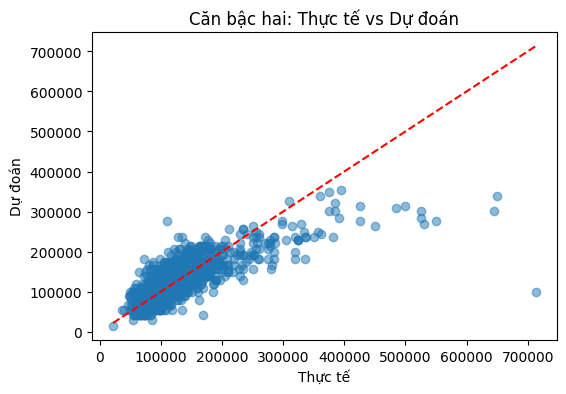


4. Mô hình với biến tương tác:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

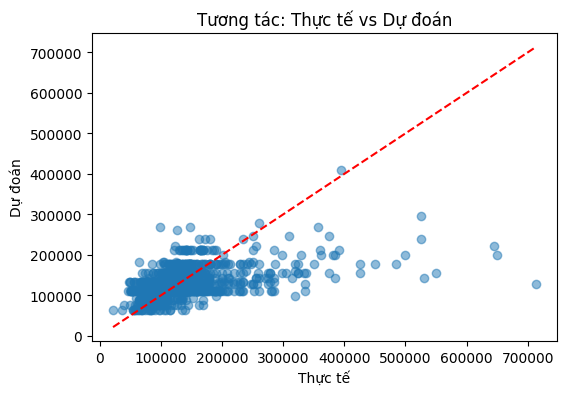


5. Mô hình đa biến với biến đổi:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

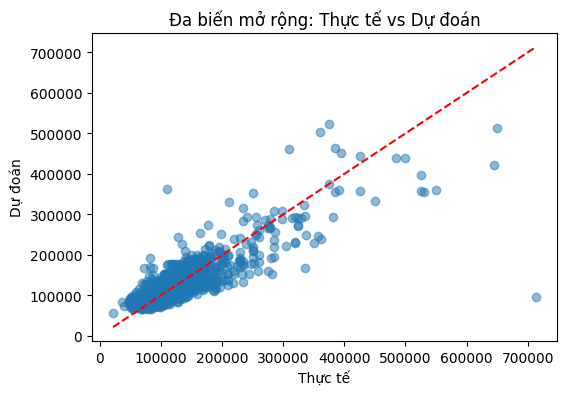


6. Mô hình với log(livarea):


<IPython.core.display.Math object>

- R²: 0.534359429035316
- RMSE: 43146.6649862465


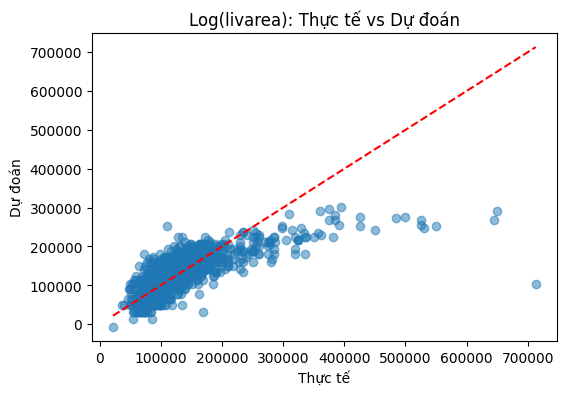


7. Mô hình với biến đổi reciprocal:


<IPython.core.display.Math object>

- R²: 0.012554299036162786
- RMSE: 62831.646101155035


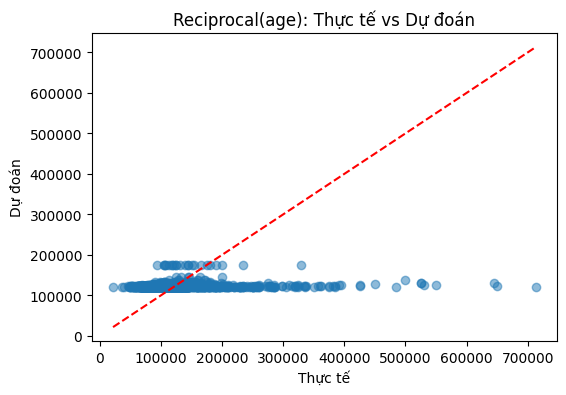


8. Mô hình polynomial bậc 2 đa biến:


<IPython.core.display.Math object>

- R²: 0.7111954449338105
- RMSE: 33980.0368447829


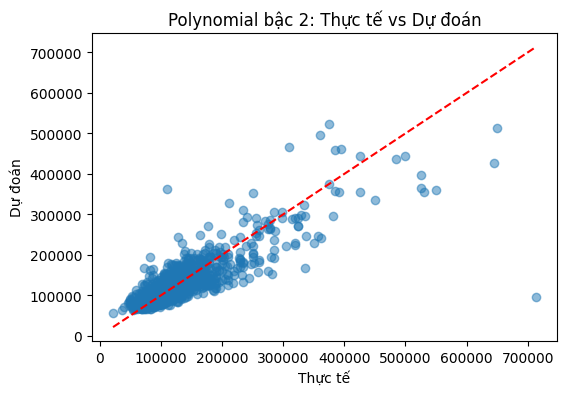


9. Mô hình với nhiều biến tương tác:


<IPython.core.display.Math object>

- R²: 0.7079895664121733
- RMSE: 34168.11425516143


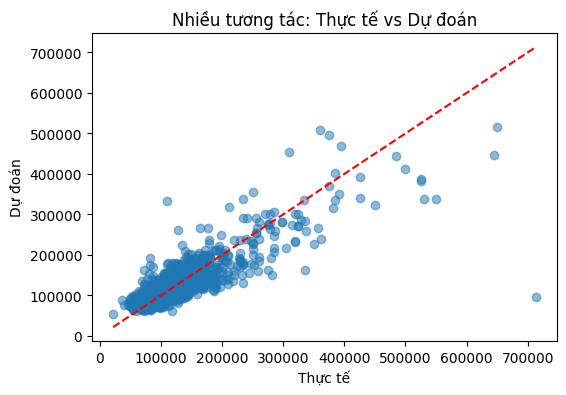


10. Mô hình tổng hợp (kết hợp nhiều biến đổi):


<IPython.core.display.Math object>

- R²: 0.7162407539609708
- RMSE: 33681.91975567202


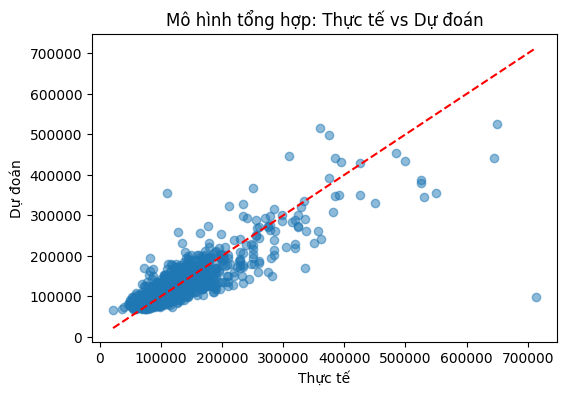

In [42]:
print("\n" + "=" * 60)
print("Câu d) BIẾN ĐỔI ĐẶC TRƯNG - MÔ HÌNH ĐA DẠNG")
print("=" * 60)

# Lưu trữ tất cả mô hình để so sánh
all_models = {}

# =====================================================
# 1. Mô hình với log(sprice)
# =====================================================
print("\n1. Mô hình với log transformation của sprice:")
log_sprice = [math.log(price) for price in sprice if price > 0]

if len(log_sprice) == len(sprice):
    log_model_livarea = simple_linear_regression(livarea, log_sprice)

    # Chuyển đổi predictions về giá gốc
    pred_sprice_from_log = [math.exp(pred) for pred in log_model_livarea['predictions']]
    residuals_original = [sprice[i] - pred_sprice_from_log[i] for i in range(len(sprice))]
    rss_original = sum(r**2 for r in residuals_original)
    rmse_original = math.sqrt(rss_original / len(sprice))

    all_models['log_sprice_livarea'] = {
        'name': 'Log(sprice) ~ livarea',
        'rmse': rmse_original,
        'r_squared': log_model_livarea['r_squared'],
        'residual_magnitude': log_model_livarea['residual_magnitude'],
        'predictions': pred_sprice_from_log
    }

    display(Math(
        rf"\log(y) = {log_model_livarea['intercept']:} + {log_model_livarea['slope']:}x_{{\text{{livarea}}}}"
    ))
    display(Math(rf"- R^2 = {log_model_livarea['r_squared']:}"))
    display(Math(rf"- RMSE = {rmse_original:}"))

    plot_actual_vs_pred(sprice, pred_sprice_from_log, title="Log transformation: Thực tế vs Dự đoán")

# =====================================================
# 2. Polynomial model (bình phương, lập phương)
# =====================================================
print("\n2. Mô hình polynomial với livarea:")

# Bình phương
livarea_sq = [x**2 for x in livarea]
sq_model = simple_linear_regression(livarea_sq, sprice)
all_models['livarea_squared'] = sq_model

display(Math(
    rf"y = {sq_model['intercept']:} + {sq_model['slope']:}x_{{\text{{livarea}}}}^2"
))
display(Math(rf"- R^2 = {sq_model['r_squared']:}"))
display(Math(rf"- RMSE = {sq_model['rmse']:}"))

plot_actual_vs_pred(sprice, sq_model['predictions'], title="Bình phương: Thực tế vs Dự đoán")

# Lập phương
livarea_cube = [x**3 for x in livarea]
cube_model = simple_linear_regression(livarea_cube, sprice)
all_models['livarea_cubed'] = cube_model

display(Math(
    rf"y = {cube_model['intercept']:} + {cube_model['slope']:}x_{{\text{{livarea}}}}^3"
))
display(Math(rf"- R^2 = {cube_model['r_squared']:}"))
display(Math(rf"- RMSE = {cube_model['rmse']:}"))

plot_actual_vs_pred(sprice, cube_model['predictions'], title="Lập phương: Thực tế vs Dự đoán")

# =====================================================
# 3. Căn bậc hai
# =====================================================
print("\n3. Mô hình căn bậc hai với livarea:")
livarea_sqrt = [math.sqrt(x) for x in livarea if x > 0]
sqrt_model = simple_linear_regression(livarea_sqrt, sprice)
all_models['livarea_sqrt'] = sqrt_model

display(Math(
    rf"y = {sqrt_model['intercept']:} + {sqrt_model['slope']:}\sqrt{{x_{{\text{{livarea}}}}}}"
))
display(Math(rf"- R^2 = {sqrt_model['r_squared']:}"))
display(Math(rf"- RMSE = {sqrt_model['rmse']:}"))

plot_actual_vs_pred(sprice, sqrt_model['predictions'], title="Căn bậc hai: Thực tế vs Dự đoán")

# =====================================================
# 4. Mô hình tương tác beds × baths
# =====================================================
print("\n4. Mô hình với biến tương tác:")
beds_baths_interaction = [beds[i] * baths[i] for i in range(len(beds))]
interaction_model = simple_linear_regression(beds_baths_interaction, sprice)
all_models['beds_baths_interaction'] = interaction_model

display(Math(
    rf"y = {interaction_model['intercept']:} + {interaction_model['slope']:} \cdot (x_{{\text{{beds}}}} \times x_{{\text{{baths}}}})"
))
display(Math(rf"- R^2 = {interaction_model['r_squared']:}"))
display(Math(rf"- RMSE = {interaction_model['rmse']:}"))

plot_actual_vs_pred(sprice, interaction_model['predictions'], title="Tương tác: Thực tế vs Dự đoán")

# =====================================================
# 5. Mô hình đa biến mở rộng
# =====================================================
print("\n5. Mô hình đa biến với biến đổi:")

X_extended = []
for i in range(len(data)):
    row = [1, livarea[i], livarea[i]**2, beds[i], baths[i],
           beds[i]*baths[i], lgelot[i], age[i], pool[i]]
    X_extended.append(row)

extended_model = multiple_linear_regression(X_extended, sprice)
all_models['extended_multivariate'] = extended_model

# In phương trình đa biến
names = ['Intercept',
    r'x_{\text{livarea}}',
    r'x_{\text{livarea}}^{2}',
    r'x_{\text{beds}}',
    r'x_{\text{baths}}',
    r'x_{\text{beds}} \times x_{\text{baths}}',
    r'x_{\text{lgelot}}',
    r'x_{\text{age}}',
    r'x_{\text{pool}}'
]

equation = rf"y = "
for i, (name, coef) in enumerate(zip(names, extended_model['coefficients'])):
    if i == 0:
        equation += f"{coef:}"
    else:
        sign = "+" if coef >= 0 else "-"
        equation += f" {sign} {abs(coef):}{name}"

display(Math(equation))
display(Math(rf"- R^2 = {extended_model['r_squared']:}"))
display(Math(rf"- RMSE = {extended_model['rmse']:}"))

plot_actual_vs_pred(sprice, extended_model['predictions'], title="Đa biến mở rộng: Thực tế vs Dự đoán")

# =====================================================
# 6. Mô hình với biến đổi log cho livarea
# =====================================================
print("\n6. Mô hình với log(livarea):")
log_livarea = [math.log(x) for x in livarea if x > 0]
log_livarea_model = simple_linear_regression(log_livarea, sprice)
all_models['log_livarea'] = {
    'name': 'sprice ~ log(livarea)',
    'residual_magnitude': log_livarea_model['residual_magnitude'],
    'rmse': log_livarea_model['rmse'],
    'r_squared': log_livarea_model['r_squared'],
    'predictions': log_livarea_model['predictions']
}

display(Math(f"y = {log_livarea_model['intercept']:} + {log_livarea_model['slope']:} * log(x_{{livarea}})"))
print(f"- R²: {log_livarea_model['r_squared']:}")
print(f"- RMSE: {log_livarea_model['rmse']:}")

plot_actual_vs_pred(sprice, log_livarea_model['predictions'], title="Log(livarea): Thực tế vs Dự đoán")

# =====================================================
# 7. Mô hình với biến đổi reciprocal (1/x)
# =====================================================
print("\n7. Mô hình với biến đổi reciprocal:")
reciprocal_age = [1/(x+1) for x in age]  # +1 để tránh chia cho 0
reciprocal_model = simple_linear_regression(reciprocal_age, sprice)
all_models['reciprocal_age'] = {
    'name': 'sprice ~ 1/(age+1)',
    'residual_magnitude': reciprocal_model['residual_magnitude'],
    'rmse': reciprocal_model['rmse'],
    'r_squared': reciprocal_model['r_squared'],
    'predictions': reciprocal_model['predictions']
}

display(Math(f"y = {reciprocal_model['intercept']:.2f} + {reciprocal_model['slope']:.2f}\\tfrac{{1}}{{x_{{age}}+1}}"))
print(f"- R²: {reciprocal_model['r_squared']:}")
print(f"- RMSE: {reciprocal_model['rmse']:}")

plot_actual_vs_pred(sprice, reciprocal_model['predictions'], title="Reciprocal(age): Thực tế vs Dự đoán")

# =====================================================
# 8. Mô hình polynomial bậc 2 đa biến
# =====================================================
print("\n8. Mô hình polynomial bậc 2 đa biến:")
X_poly2 = []
for i in range(len(data)):
    row = [1,  # intercept
           livarea[i],  # livarea
           livarea[i]**2,  # livarea²
           beds[i],
           beds[i]**2,  # beds²
           baths[i],
           baths[i]**2,  # baths²
           age[i],
           age[i]**2,  # age²
           lgelot[i],
           pool[i]]
    X_poly2.append(row)

poly2_model = multiple_linear_regression(X_poly2, sprice)
all_models['polynomial_degree2'] = {
    'name': 'Polynomial bậc 2',
    'residual_magnitude': poly2_model['residual_magnitude'],
    'rmse': poly2_model['rmse'],
    'r_squared': poly2_model['r_squared'],
    'predictions': poly2_model['predictions']
}

def format_term(coef, var):
    if coef >= 0:
        return f" + {coef} {var}"
    else:
        return f" - {abs(coef)} {var}"

coef = poly2_model['coefficients']

expr = f"y = {coef[0]}"
expr += format_term(coef[1], r"x_{livarea}^2")
expr += format_term(coef[2], r"x_{beds}^2")
expr += format_term(coef[3], r"x_{baths}^2")
expr += format_term(coef[4], r"x_{age}^2")
expr += format_term(coef[5], r"x_{lgelot}^2")
expr += format_term(coef[6], r"x_{pool}^2")
expr += format_term(coef[7], r"x_{livarea}^2")

display(Math(expr))
print(f"- R²: {poly2_model['r_squared']:}")
print(f"- RMSE: {poly2_model['rmse']:}")

plot_actual_vs_pred(sprice, poly2_model['predictions'], title="Polynomial bậc 2: Thực tế vs Dự đoán")

# =====================================================
# 9. Mô hình với nhiều tương tác
# =====================================================
print("\n9. Mô hình với nhiều biến tương tác:")
X_interactions = []
for i in range(len(data)):
    row = [1,  # intercept
           livarea[i],
           beds[i],
           baths[i],
           age[i],
           lgelot[i],
           pool[i],
           livarea[i] * beds[i],  # livarea × beds
           livarea[i] * baths[i],  # livarea × baths
           beds[i] * baths[i],  # beds × baths
           livarea[i] * pool[i],  # livarea × pool
           age[i] * pool[i]]  # age × pool
    X_interactions.append(row)

interactions_model = multiple_linear_regression(X_interactions, sprice)
all_models['multiple_interactions'] = {
    'name': 'Nhiều tương tác',
    'residual_magnitude': interactions_model['residual_magnitude'],
    'rmse': interactions_model['rmse'],
    'r_squared': interactions_model['r_squared'],
    'predictions': interactions_model['predictions']
}

coef = interactions_model['coefficients']
expr = f"y = {coef[0]:.2f}"
expr += format_term(coef[1], r"x_{livarea}")
expr += format_term(coef[2], r"x_{beds}")
expr += format_term(coef[3], r"x_{baths}")
expr += format_term(coef[4], r"x_{age}")
expr += format_term(coef[5], r"x_{lgelot}")
expr += format_term(coef[6], r"x_{pool}")
expr += format_term(coef[7], r"(x_{livarea} \times x_{beds})")
expr += format_term(coef[8], r"(x_{livarea}\ \times x_{baths})")
expr += format_term(coef[9], r"(x_{beds} \times x_{baths})")
expr += format_term(coef[10], r"(x_{livarea} \\times x_{pool})")
expr += format_term(coef[11], r"(x_{age} \times x_{pool})")

display(Math(expr))
print(f"- R²: {interactions_model['r_squared']:}")
print(f"- RMSE: {interactions_model['rmse']:}")

plot_actual_vs_pred(sprice, interactions_model['predictions'], title="Nhiều tương tác: Thực tế vs Dự đoán")

# =====================================================
# 10. Mô hình kết hợp tất cả
# =====================================================
print("\n10. Mô hình tổng hợp (kết hợp nhiều biến đổi):")
X_comprehensive = []
for i in range(len(data)):
    row = [1,  # intercept
           livarea[i],  # livarea
           livarea[i]**2,  # livarea²
           math.log(livarea[i]),  # log(livarea)
           beds[i],
           beds[i]**2,  # beds²
           baths[i],
           baths[i]**2,  # baths²
           beds[i] * baths[i],  # beds × baths
           livarea[i] * beds[i],  # livarea × beds
           age[i],
           1/(age[i]+1),  # 1/(age+1)
           lgelot[i],
           pool[i],
           livarea[i] * pool[i]]  # livarea × pool
    X_comprehensive.append(row)

comprehensive_model = multiple_linear_regression(X_comprehensive, sprice)
all_models['comprehensive'] = {
    'name': 'Mô hình tổng hợp',
    'residual_magnitude': comprehensive_model['residual_magnitude'],
    'rmse': comprehensive_model['rmse'],
    'r_squared': comprehensive_model['r_squared'],
    'predictions': comprehensive_model['predictions']
}

coef = comprehensive_model['coefficients']
expr  = f"y = {coef[0]:.2f}"
expr += format_term(coef[1],  r"x_{livarea}")
expr += format_term(coef[2],  r"x_{livarea}^2")
expr += format_term(coef[3],  r"\log(x_{livarea})")
expr += format_term(coef[4],  r"x_{beds}")
expr += format_term(coef[5],  r"x_{beds}^2")
expr += format_term(coef[6],  r"x_{baths}")
expr += format_term(coef[7],  r"x_{baths}^2")
expr += format_term(coef[8],  r"(x_{beds} \times x_{baths})")
expr += format_term(coef[9],  r"(x_{livarea} \times x_{beds})")
expr += format_term(coef[10], r"x_{age}")
expr += format_term(coef[11], r"\tfrac{1}{x_{age}+1}")
expr += format_term(coef[12], r"x_{lgelot}")
expr += format_term(coef[13], r"x_{pool}")
expr += format_term(coef[14], r"(x_{livarea} \times x_{pool})")

display(Math(expr))
print(f"- R²: {comprehensive_model['r_squared']:}")
print(f"- RMSE: {comprehensive_model['rmse']:}")

plot_actual_vs_pred(sprice, comprehensive_model['predictions'], title="Mô hình tổng hợp: Thực tế vs Dự đoán")


TỔNG KẾT SO SÁNH TẤT CẢ CÁC MÔ HÌNH


Tên mô hình                  R²       RMSE       Res_Magnitude  
-----------------------------------------------------------------
Mô hình tổng hợp               0.7162   33682      1304495        
Polynomial bậc 2               0.7112   33980      1316041        
extended_multivariate          0.7088   34121      1321496        
Nhiều tương tác                0.7080   34168      1323325        
Đa biến gốc                    0.6944   34954      1353757        
livarea_squared                0.6613   36801      1425299        
Log(sprice) ~ livarea          0.6566   38236      9              
Đơn biến tốt nhất (livarea)    0.6287   38531      1492303        
livarea_cubed                  0.6115   39409      1526301        
livarea_sqrt                   0.5862   40673      1575253        
sprice ~ log(livarea)          0.5344   43147      1671063        
beds_baths_interaction         0.2670   54135      2096633        
sprice ~ 1/(age+1)        

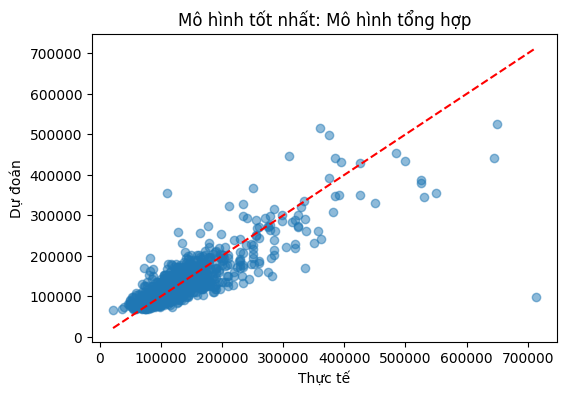

In [43]:
# So sánh tất cả các mô hình
print("\n" + "=" * 80)
print("TỔNG KẾT SO SÁNH TẤT CẢ CÁC MÔ HÌNH")
print("=" * 80)

# Thêm mô hình gốc vào để so sánh
all_models['original_multivariate'] = {
    'name': 'Đa biến gốc',
    'residual_magnitude': multi_model['residual_magnitude'],
    'rmse': multi_model['rmse'],
    'r_squared': multi_model['r_squared'],
    'predictions': multi_model['predictions']
}

all_models['best_single'] = {
    'name': f'Đơn biến tốt nhất ({best_single[0]})',
    'residual_magnitude': best_single[1]['residual_magnitude'],
    'rmse': best_single[1]['rmse'],
    'r_squared': best_single[1]['r_squared'],
    'predictions': best_single[1]['predictions']
}

print(f"{'\n\nTên mô hình':<30} {'R²':<8} {'RMSE':<10} {'Res_Magnitude':<15}")
print("-" * 65)

# Sắp xếp theo R² giảm dần
sorted_models = sorted(all_models.items(), key=lambda x: x[1]['r_squared'], reverse=True)

for model_key, model_info in sorted_models:
    name = model_info.get("name", model_key)  # fallback: nếu không có 'name' thì lấy key
    print(f"{name:<30} {model_info['r_squared']:<8.4f} "
          f"{model_info['rmse']:<10.0f} {model_info['residual_magnitude']:<15.0f}")


# Tìm mô hình tốt nhất
best_model_key, best_model_info = sorted_models[0]
print(f"\n** MÔ HÌNH TỐI ƯU: {best_model_info['name']}")
print(f"   - R²: {best_model_info['r_squared']:}")
print(f"   - RMSE: {best_model_info['rmse']:}")
print(f"   - Độ lớn vector phần dư: {best_model_info['residual_magnitude']:}")

# Vẽ biểu đồ cho mô hình tốt nhất
plot_actual_vs_pred(sprice, best_model_info['predictions'],
                   title=f"Mô hình tốt nhất: {best_model_info['name']}")



## **Bài 2. Xích Markov dự đoán giao thông** <a id="c8"></a>

In [44]:
import random

# a) Tạo dữ liệu mô phỏng
def generate_traffic_data(n_days=60):
    """
    Tạo chuỗi dữ liệu giao thông trong n ngày
    K - Kẹt xe, B - Bình thường, T - Thoáng
    """
    states = ['K', 'B', 'T']
    data = [random.choice(states) for _ in range(n_days)]
    return data

# b) Xây dựng ma trận đếm số lần chuyển trạng thái
def build_transition_count_matrix(data):
    """
    Đếm số lần chuyển từ trạng thái này sang trạng thái khác
    """
    states = ['K', 'B', 'T']
    count_matrix = [[0 for _ in range(3)] for _ in range(3)]

    for i in range(len(data) - 1):
        current_state = data[i]
        next_state = data[i + 1]

        current_idx = states.index(current_state)
        next_idx = states.index(next_state)

        count_matrix[current_idx][next_idx] += 1

    return count_matrix

# c) Tính toán ma trận xác suất chuyển
def normalize_transition_matrix(count_matrix):
    """
    Chuẩn hóa ma trận đếm thành ma trận xác suất chuyển
    """
    prob_matrix = [[0.0 for _ in range(3)] for _ in range(3)]

    for i in range(3):
        row_sum = sum(count_matrix[i])
        if row_sum > 0:
            for j in range(3):
                prob_matrix[i][j] = count_matrix[i][j] / row_sum
        else:
            # Nếu không có chuyển đổi nào từ trạng thái i, phân bố đều
            for j in range(3):
                prob_matrix[i][j] = 1/3

    return prob_matrix

# d) Dự đoán trạng thái các ngày tiếp theo
def multiply_vector_matrix(vector, matrix):
    """
    Nhân vector hàng với ma trận
    """
    result = [0.0] * len(matrix[0])
    for i in range(len(matrix[0])):
        for j in range(len(vector)):
            result[i] += vector[j] * matrix[j][i]
    return result

def prop_distribution(k, transition_matrix):
    """
    Tính phân phối xác suất sau k ngày
    Giả định ban đầu các trạng thái có xác suất bằng nhau
    """
    # Phân phối ban đầu (đều nhau)
    current_dist = [1/3, 1/3, 1/3]

    # Nhân k lần với ma trận chuyển
    for _ in range(k):
        current_dist = multiply_vector_matrix(current_dist, transition_matrix)

    return current_dist

# e) Tìm phân phối dừng
def multiply_matrices(A, B):
    """
    Nhân hai ma trận A và B
    """
    rows_A, cols_A = len(A), len(A[0])
    rows_B, cols_B = len(B), len(B[0])

    if cols_A != rows_B:
        raise ValueError("Không thể nhân hai ma trận")

    result = [[0.0 for _ in range(cols_B)] for _ in range(rows_A)]

    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]

    return result

def prop_sta(transition_matrix, iterations=100):
    """
    Tìm phân phối dừng bằng cách lũy thừa ma trận
    """
    # Bắt đầu với ma trận chuyển gốc
    P_power = [row[:] for row in transition_matrix]  # Copy ma trận

    # Lũy thừa ma trận nhiều lần
    for _ in range(iterations):
        P_power = multiply_matrices(P_power, transition_matrix)

    # Phân phối dừng là hàng đầu tiên của ma trận lũy thừa
    return P_power[0]

# Hàm in ma trận đẹp
def print_matrix(matrix, title="", states=['K', 'B', 'T']):
    """
    In ma trận với format đẹp
    """
    print(f"\n{title}")
    print("    ", end="")
    for state in states:
        print(f"{state:>8}", end="")
    print()

    for i, row in enumerate(matrix):
        print(f"{states[i]:>3} ", end="")
        for val in row:
            print(f"{val:>8.4f}", end="")
        print()

### **a) Tạo dữ liệu mô phỏng** <a id="c9"></a>

* Sinh chuỗi trạng thái 60 ngày (`K`, `B`, `T`) với xác suất bằng nhau.
* In chuỗi dữ liệu.

In [45]:
print("\n" + "=" * 60)
print("Câu a) TẠO DỮ LIỆU MÔ PHỎNG")
print("=" * 60)

# Tạo chuỗi 60 ngày
traffic_data = generate_traffic_data(60)
print("Chuỗi trạng thái giao thông 60 ngày:")
print(''.join(traffic_data))

# Thống kê phân phối
from collections import Counter
count = Counter(traffic_data)
print(f"\nThống kê phân phối: K = {count['K']}; B = {count['B']}; T = {count['T']}")


Câu a) TẠO DỮ LIỆU MÔ PHỎNG
Chuỗi trạng thái giao thông 60 ngày:
TKKBKTBBTTBKTTBTTBBTKKKBBTKTKBTTTTKKTTKTBBBBTTTTBKBKTKTKBBBB

Thống kê phân phối: K = 16; B = 20; T = 24


### **b) Ma trận đếm số lần chuyển trạng thái** <a id="c10"></a>

* Xây dựng bảng 3x3 (từ K, B, T → K, B, T).
* Điền số lần chuyển thực tế quan sát được trong dữ liệu.

In [46]:
print("\n" + "=" * 60)
print("Câu b) MA TRẬN ĐẾM SỐ LẦN CHUYỂN TRẠNG THÁI")
print("=" * 60)

count_matrix = build_transition_count_matrix(traffic_data)
print_matrix(count_matrix, "Ma trận đếm số lần chuyển trạng thái:")

# Tổng số chuyển đổi
total_transitions = sum(sum(row) for row in count_matrix)
print(f"\nTổng số lần chuyển đổi: {total_transitions}")


Câu b) MA TRẬN ĐẾM SỐ LẦN CHUYỂN TRẠNG THÁI

Ma trận đếm số lần chuyển trạng thái:
           K       B       T
  K   4.0000  5.0000  7.0000
  B   4.0000  9.0000  6.0000
  T   8.0000  6.0000 10.0000

Tổng số lần chuyển đổi: 59


### **c) Ma trận xác suất chuyển** <a id="c11"></a>

* Chuẩn hóa ma trận đếm để tính xác suất chuyển trạng thái.
* Mỗi hàng tổng = 1.

In [47]:
print("\n" + "=" * 60)
print("Câu c) MA TRẬN XÁC SUẤT CHUYỂN")
print("=" * 60)

transition_matrix = normalize_transition_matrix(count_matrix)
print_matrix(transition_matrix, "Ma trận xác suất chuyển trạng thái:")

# Kiểm tra tổng mỗi hàng = 1
print("\nKiểm tra tổng mỗi hàng (phải bằng 1):")
states = ['K', 'B', 'T']
for i, row in enumerate(transition_matrix):
    print(f"Hàng {states[i]}: {sum(row):.6f}")


Câu c) MA TRẬN XÁC SUẤT CHUYỂN

Ma trận xác suất chuyển trạng thái:
           K       B       T
  K   0.2500  0.3125  0.4375
  B   0.2105  0.4737  0.3158
  T   0.3333  0.2500  0.4167

Kiểm tra tổng mỗi hàng (phải bằng 1):
Hàng K: 1.000000
Hàng B: 1.000000
Hàng T: 1.000000


### **d) Dự đoán trạng thái sau k ngày** <a id="c12"></a>

* Viết hàm `prop_distribution(k)` tính phân phối xác suất sau k ngày, giả sử ngày hiện tại các trạng thái có xác suất bằng nhau.
* Tính phân phối cho k = 1, 2, 3, 10.
* In kết quả dưới dạng bảng.

In [48]:
print("\n" + "=" * 60)
print("Câu d) DỰ ĐOÁN TRẠNG THÁI CÁC NGÀY TIẾP THEO")
print("=" * 60)

print("Phân phối xác suất sau k ngày (giả định ban đầu đều nhau):")
print(f"{'Ngày':<6} {'K (Kẹt)':<10} {'B (Bình thường)':<15} {'T (Thoáng)':<12} {'Tổng':<8}")
print("-" * 55)

for k in [1, 2, 3, 10]:
    dist = prop_distribution(k, transition_matrix)
    total = sum(dist)
    print(f"{k:<6} {dist[0]:<10.4f} {dist[1]:<15.4f} {dist[2]:<12.4f} {total:<8.4f}")

# Kiểm tra xu hướng hội tụ
print("\nXu hướng hội tụ về phân phối dừng:")
print(f"{'Ngày':<6} {'K (Kẹt)':<10} {'B (Bình thường)':<15} {'T (Thoáng)':<12}")
print("-" * 47)

for k in [1, 5, 10, 20, 50, 100]:
    dist = prop_distribution(k, transition_matrix)
    print(f"{k:<6} {dist[0]:<10.4f} {dist[1]:<15.4f} {dist[2]:<12.4f}")


Câu d) DỰ ĐOÁN TRẠNG THÁI CÁC NGÀY TIẾP THEO
Phân phối xác suất sau k ngày (giả định ban đầu đều nhau):
Ngày   K (Kẹt)    B (Bình thường) T (Thoáng)   Tổng    
-------------------------------------------------------
1      0.2646     0.3454          0.3900       1.0000  
2      0.2689     0.3438          0.3873       1.0000  
3      0.2687     0.3437          0.3876       1.0000  
10     0.2687     0.3437          0.3876       1.0000  

Xu hướng hội tụ về phân phối dừng:
Ngày   K (Kẹt)    B (Bình thường) T (Thoáng)  
-----------------------------------------------
1      0.2646     0.3454          0.3900      
5      0.2687     0.3437          0.3876      
10     0.2687     0.3437          0.3876      
20     0.2687     0.3437          0.3876      
50     0.2687     0.3437          0.3876      
100    0.2687     0.3437          0.3876      


### **e) Tìm phân phối dừng** <a id="c13"></a>

* Viết hàm `prop_sta()` để tìm phân phối dừng (nghiệm của $\pi P = \pi$).
* Xuất phân phối dừng tìm được.
* So sánh với phân phối mô phỏng từ dữ liệu.

In [49]:
print("\n" + "=" * 60)
print("Câu e) TÌM PHÂN PHỐI DỪNG")
print("=" * 60)

stationary_dist = prop_sta(transition_matrix)
print("Phân phối dừng của xích Markov:")
print(f"{'Trạng thái':<14} {'Xác suất':<12} {'Phần trăm':<12}")
print("-" * 36)

states = ['K (Kẹt xe)', 'B (Bình thường)', 'T (Thoáng)']
for i, (state, prob) in enumerate(zip(states, stationary_dist)):
    print(f"{state:<15} {prob:<12.6f} {prob*100:<.2f}%")

print(f"\nTổng xác suất: {sum(stationary_dist):.6f}")

# So sánh với phân phối thực tế từ dữ liệu
total_days = len(traffic_data)
empirical_dist = [count['K']/total_days, count['B']/total_days, count['T']/total_days]

print(f"\nSo sánh phân phối dừng lý thuyết với phân phối thực tế từ dữ liệu:")
print(f"{'Trạng thái':<12} {'Lý thuyết':<12} {'Thực tế':<12} {'Chênh lệch':<12}")
print("-" * 48)

state_names = ['K', 'B', 'T']
for i, state in enumerate(state_names):
    diff = abs(stationary_dist[i] - empirical_dist[i])
    print(f"{state:<12} {stationary_dist[i]:<12.6f} {empirical_dist[i]:<12.6f} {diff:<12.6f}")

# Kiểm tra tính chất của phân phối dừng
print(f"\nKiểm tra tính chất phân phối dừng:")
print("Nếu π là phân phối dừng thì π × P = π")

# Tính π × P
pi_P = multiply_vector_matrix(stationary_dist, transition_matrix)
print(f"π = [{stationary_dist[0]:.6f}, {stationary_dist[1]:.6f}, {stationary_dist[2]:.6f}]")
print(f"π×P = [{pi_P[0]:.6f}, {pi_P[1]:.6f}, {pi_P[2]:.6f}]")

# Tính sai số
error = sum(abs(stationary_dist[i] - pi_P[i]) for i in range(3))
print(f"Tổng sai số tuyệt đối: {error:.8f}")

if error < 1e-6:
    print("✓ Xác nhận π là phân phối dừng (sai số < 10⁻⁶)")
else:
    print("⚠ Cần kiểm tra lại tính toán")

# Diễn giải kết quả
print(f"\n" + "=" * 60)
print("DIỄN GIẢI KẾT QUẢ")
print("=" * 60)

max_prob_idx = stationary_dist.index(max(stationary_dist))
max_state = ['Kẹt xe', 'Bình thường', 'Thoáng'][max_prob_idx]

print(f"Kết quả phân tích xích Markov cho tuyến đường:")
print(f"• Trong dài hạn, trạng thái '{max_state}' có xác suất cao nhất ({max(stationary_dist)*100:.2f}%)")
print(f"• Xác suất dài hạn: Kẹt xe {stationary_dist[0]*100:.2f}%, "
      f"Bình thường {stationary_dist[1]*100:.2f}%, Thoáng {stationary_dist[2]*100:.2f}%")

# Phân tích ma trận chuyển
print(f"\nĐặc điểm của ma trận chuyển trạng thái:")
for i, from_state in enumerate(['Kẹt xe', 'Bình thường', 'Thoáng']):
    max_transition_idx = transition_matrix[i].index(max(transition_matrix[i]))
    max_to_state = ['Kẹt xe', 'Bình thường', 'Thoáng'][max_transition_idx]
    prob = transition_matrix[i][max_transition_idx]
    print(f"• Từ {from_state}: có xu hướng chuyển sang {max_to_state} ({prob*100:.1f}%)")


Câu e) TÌM PHÂN PHỐI DỪNG
Phân phối dừng của xích Markov:
Trạng thái     Xác suất     Phần trăm   
------------------------------------
K (Kẹt xe)      0.268734     26.87%
B (Bình thường) 0.343669     34.37%
T (Thoáng)      0.387597     38.76%

Tổng xác suất: 1.000000

So sánh phân phối dừng lý thuyết với phân phối thực tế từ dữ liệu:
Trạng thái   Lý thuyết    Thực tế      Chênh lệch  
------------------------------------------------
K            0.268734     0.266667     0.002067    
B            0.343669     0.333333     0.010336    
T            0.387597     0.400000     0.012403    

Kiểm tra tính chất phân phối dừng:
Nếu π là phân phối dừng thì π × P = π
π = [0.268734, 0.343669, 0.387597]
π×P = [0.268734, 0.343669, 0.387597]
Tổng sai số tuyệt đối: 0.00000000
✓ Xác nhận π là phân phối dừng (sai số < 10⁻⁶)

DIỄN GIẢI KẾT QUẢ
Kết quả phân tích xích Markov cho tuyến đường:
• Trong dài hạn, trạng thái 'Thoáng' có xác suất cao nhất (38.76%)
• Xác suất dài hạn: Kẹt xe 26.87%, Bình thườn

# =============================================================================
# **MÔ TẢ Ý TƯỞNG THỰC HIỆN VÀ CÁC HÀM**
# =============================================================================

## **Mô tả ý tưởng thực hiện** <a id="c14"></a>

### **Bài toán 1: Hồi quy tuyến tính dự đoán giá nhà**

*   **Ý tưởng chính:** Xây dựng và so sánh nhiều mô hình hồi quy tuyến tính để tìm ra phương pháp dự đoán giá nhà (`sprice`) tốt nhất từ các đặc trưng có sẵn. Quá trình thực hiện tuân theo một quy trình khoa học dữ liệu chuẩn mực.
*   **Các bước thực hiện:**
    1.  **Khám phá và chuẩn bị dữ liệu (EDA):** Bắt đầu bằng việc đọc dữ liệu từ file CSV, sau đó tính toán các đại lượng thống kê cơ bản (trung bình, độ lệch chuẩn, v.v.) và phân tích mối tương quan giữa các biến thông qua ma trận tương quan và các biểu đồ trực quan (scatter plot, box plot). Bước này giúp hiểu rõ hơn về bản chất của dữ liệu và định hướng cho việc xây dựng mô hình.
    2.  **Xây dựng mô hình cơ sở (Baseline):** Xây dựng các mô hình hồi quy tuyến tính đơn biến, mỗi mô hình sử dụng một đặc trưng duy nhất để dự đoán giá nhà. Các mô hình này được đánh giá dựa trên độ lớn của vector phần dư và hệ số R² để xác định đặc trưng nào có khả năng giải thích tốt nhất khi đứng một mình.
    3.  **Xây dựng mô hình đa biến:** Kết hợp tất cả các đặc trưng vào một mô hình hồi quy tuyến tính đa biến. Mô hình này được giải quyết bằng phương pháp đại số tuyến tính, cụ thể là giải hệ phương trình `(X^T * X)β = X^T * y` bằng phương pháp khử Gauss tự cài đặt.
    4.  **Cải thiện mô hình (Feature Engineering):** Thử nghiệm các phép biến đổi trên dữ liệu để nắm bắt các mối quan hệ phức tạp hơn. Các kỹ thuật được sử dụng bao gồm:
        *   Biến đổi logarit trên biến mục tiêu (`sprice`).
        *   Tạo đặc trưng bậc cao (đa thức) như `livarea²`, `livarea³`.
        *   Tạo đặc trưng tương tác giữa các biến, ví dụ như `beds * baths`.
        *   Xây dựng một mô hình tổng hợp, kết hợp nhiều phép biến đổi khác nhau để tối ưu hóa kết quả.
    5.  **Đánh giá và lựa chọn:** Tất cả các mô hình đã xây dựng được so sánh với nhau dựa trên hai chỉ số chính là R² (mức độ phù hợp) và RMSE (sai số dự đoán trung bình). Mô hình có R² cao nhất và RMSE thấp nhất được chọn là mô hình tối ưu.

### **Bài toán 2: Xích Markov mô phỏng giao thông**

*   **Ý tưởng chính:** Ứng dụng mô hình toán học Xích Markov để mô phỏng và dự đoán xu hướng giao thông dựa trên chuỗi trạng thái trong quá khứ.
*   **Các bước thực hiện:**
    1.  **Mô phỏng dữ liệu:** Tạo một chuỗi dữ liệu giả lập về tình trạng giao thông trong 60 ngày, với ba trạng thái: Kẹt xe (K), Bình thường (B), và Thoáng (T).
    2.  **Xây dựng ma trận chuyển đổi:**
        *   Từ chuỗi dữ liệu, xây dựng **ma trận đếm** để thống kê số lần chuyển từ một trạng thái này sang một trạng thái khác trong hai ngày liên tiếp.
        *   Chuẩn hóa ma trận đếm bằng cách chia mỗi phần tử cho tổng của hàng tương ứng để thu được **ma trận xác suất chuyển**. Ma trận này biểu diễn xác suất để hệ thống chuyển sang một trạng thái mới, biết trạng thái hiện tại.
    3.  **Dự đoán tương lai:** Sử dụng ma trận xác suất chuyển để dự đoán phân phối xác suất của các trạng thái giao thông sau `k` ngày, bắt đầu từ một phân phối xác suất ban đầu (giả định là đồng đều).
    4.  **Tìm phân phối dừng (dài hạn):** Tính toán phân phối xác suất ổn định của hệ thống, tức là phân phối mà tại đó xác suất của các trạng thái không còn thay đổi theo thời gian. Điều này được thực hiện bằng cách lũy thừa ma trận chuyển lên một bậc đủ lớn và phân phối dừng chính là các hàng của ma trận kết quả. Phân phối này cho thấy xu hướng dài hạn của tình trạng giao thông trên tuyến đường.


## **Mô tả các hàm** <a id="15"></a>

**Bài toán 1: Dự đoán giá nhà**

**Nhóm 1: Các hàm xử lý dữ liệu và thống kê**

*   **Tên hàm:** `calculate_stats(data_list)`
    *   **Mô tả:** Tính toán các đại lượng thống kê mô tả cơ bản cho một danh sách (list) chứa dữ liệu số.
    *   **Input:**
        *   `data_list` (list of float/int): Danh sách các giá trị số cần thống kê.
    *   **Output:**
        *   Một `dictionary` chứa các giá trị sau: `mean` (trung bình), `std` (độ lệch chuẩn), `min` (giá trị nhỏ nhất), `max` (giá trị lớn nhất), và `count` (số lượng phần tử).

*   **Tên hàm:** `correlation(x, y)`
    *   **Mô tả:** Tính toán hệ số tương quan Pearson giữa hai danh sách dữ liệu số. Hệ số này đo lường mức độ mạnh yếu của mối quan hệ tuyến tính giữa hai biến.
    *   **Input:**
        *   `x` (list of float/int): Danh sách dữ liệu của biến thứ nhất.
        *   `y` (list of float/int): Danh sách dữ liệu của biến thứ hai (phải có cùng độ dài với `x`).
    *   **Output:**
        *   Một giá trị `float` là hệ số tương quan, nằm trong khoảng từ -1 đến 1.

**Nhóm 2: Các hàm hồi quy tuyến tính**

*   **Tên hàm:** `simple_linear_regression(x, y)`
    *   **Mô tả:** Xây dựng mô hình hồi quy tuyến tính đơn biến theo công thức `y = a + bx`. Hàm tính toán các hệ số `a` (intercept) và `b` (slope) bằng phương pháp bình phương tối thiểu, đồng thời cung cấp các chỉ số để đánh giá mô hình.
    *   **Input:**
        *   `x` (list of float/int): Dữ liệu của biến độc lập.
        *   `y` (list of float/int): Dữ liệu của biến phụ thuộc.
    *   **Output:**
        *   Một `dictionary` chứa các thông tin về mô hình: `intercept`, `slope`, `predictions` (danh sách các giá trị dự đoán), `residuals` (danh sách các phần dư), `rss` (tổng bình phương phần dư), `residual_magnitude` (độ lớn vector phần dư), `r_squared` (hệ số xác định R²), và `rmse` (sai số toàn phương trung bình).

*   **Tên hàm:** `multiple_linear_regression(X, y)`
    *   **Mô tả:** Xây dựng mô hình hồi quy tuyến tính đa biến bằng phương pháp đại số tuyến tính. Hàm giải hệ phương trình `(X^T * X)β = X^T * y` để tìm ra vector hệ số `β`.
    *   **Input:**
        *   `X` (list of lists of float): Ma trận đặc trưng, trong đó mỗi hàng là một quan sát và cột đầu tiên phải là 1 (đại diện cho intercept).
        *   `y` (list of float): Vector giá trị mục tiêu.
    *   **Output:**
        *   Một `dictionary` chứa `coefficients` (vector hệ số `β`) và các chỉ số đánh giá mô hình tương tự như hàm hồi quy đơn biến.

*   **Tên hàm:** `gaussian_elimination(A, b)`
    *   **Mô tả:** Hàm tiện ích dùng để giải một hệ phương trình tuyến tính có dạng `Ax = b` bằng phương pháp khử Gauss, bao gồm quá trình khử xuôi và thế ngược.
    *   **Input:**
        *   `A` (list of lists of float): Ma trận hệ số.
        *   `b` (list of float): Vector hằng số.
    *   **Output:**
        *   Một `list of float` là vector nghiệm `x` của hệ phương trình.

**Nhóm 3: Các hàm trực quan hóa**

*   **Tên hàm:** `plot_scatter(x, y, y_pred, xlabel, ylabel, title)`
    *   **Mô tả:** Vẽ biểu đồ phân tán (scatter plot) để thể hiện mối quan hệ giữa hai biến `x` và `y`. Có thể tùy chọn vẽ thêm đường hồi quy (`y_pred`) lên trên biểu đồ.
    *   **Input:**
        *   `x`, `y` (list of float/int): Dữ liệu cho các trục.
        *   `y_pred` (list of float, optional): Dữ liệu dự đoán để vẽ đường hồi quy.
        *   `xlabel`, `ylabel`, `title` (string): Các nhãn cho biểu đồ.
    *   **Output:** Hiển thị một biểu đồ Matplotlib.

*   **Tên hàm:** `plot_boxplot(x, y, xlabel, ylabel, title)`
    *   **Mô tả:** Vẽ biểu đồ hộp (box plot) để so sánh phân phối của biến `y` theo từng nhóm của biến `x` (biến phân loại).
    *   **Input:**
        *   `x` (list): Dữ liệu của biến phân loại.
        *   `y` (list): Dữ liệu của biến liên tục.
        *   `xlabel`, `ylabel`, `title` (string): Các nhãn cho biểu đồ.
    *   **Output:** Hiển thị một biểu đồ Matplotlib.

*   **Tên hàm:** `plot_correlation_matrix(data_dict)`
    *   **Mô tả:** Tính toán và vẽ một ma trận tương quan dạng heatmap cho tất cả các biến trong `data_dict`. Giá trị tương quan được hiển thị trực tiếp trên các ô màu.
    *   **Input:**
        *   `data_dict` (dictionary): Một từ điển với key là tên biến và value là danh sách dữ liệu của biến đó.
    *   **Output:** Hiển thị một biểu đồ Matplotlib.

*   **Tên hàm:** `plot_actual_vs_pred(y, y_pred, title)`
    *   **Mô tả:** Vẽ biểu đồ so sánh giữa giá trị thực tế (`y`) và giá trị dự đoán (`y_pred`). Một đường thẳng `y=x` được vẽ thêm để làm tham chiếu cho độ chính xác của mô hình.
    *   **Input:**
        *   `y` (list): Các giá trị thực tế.
        *   `y_pred` (list): Các giá trị dự đoán tương ứng.
        *   `title` (string): Tiêu đề biểu đồ.
    *   **Output:** Hiển thị một biểu đồ Matplotlib.

**Bài toán 2: Xích Markov dự đoán giao thông**

*   **Tên hàm:** `generate_traffic_data(n_days)`
    *   **Mô tả:** Tạo ra một chuỗi dữ liệu ngẫu nhiên mô phỏng tình trạng giao thông ('K', 'B', 'T') trong một khoảng thời gian cho trước.
    *   **Input:**
        *   `n_days` (int): Số ngày cần mô phỏng.
    *   **Output:**
        *   Một `list` chứa các chuỗi ký tự ('K', 'B', 'T') đại diện cho trạng thái giao thông mỗi ngày.

*   **Tên hàm:** `build_transition_count_matrix(data)`
    *   **Mô tả:** Xây dựng một ma trận 3x3 để đếm số lần chuyển đổi từ một trạng thái sang một trạng thái khác dựa trên chuỗi dữ liệu đầu vào.
    *   **Input:**
        *   `data` (list of string): Chuỗi trạng thái giao thông đã quan sát.
    *   **Output:**
        *   Một ma trận (list of lists) 3x3 chứa số lần chuyển đổi.

*   **Tên hàm:** `normalize_transition_matrix(count_matrix)`
    *   **Mô tả:** Chuyển đổi ma trận đếm thành ma trận xác suất chuyển. Mỗi phần tử trong ma trận kết quả biểu diễn xác suất chuyển từ trạng thái hàng `i` sang trạng thái cột `j`.
    *   **Input:**
        *   `count_matrix` (list of lists of int): Ma trận đếm.
    *   **Output:**
        *   Một ma trận (list of lists) 3x3 chứa các xác suất chuyển.

*   **Tên hàm:** `prop_distribution(k, transition_matrix)`
    *   **Mô tả:** Tính toán phân phối xác suất của các trạng thái sau `k` bước (ngày) dựa trên ma trận xác suất chuyển. Hàm giả định phân phối ban đầu là đồng đều (mỗi trạng thái có xác suất 1/3).
    *   **Input:**
        *   `k` (int): Số ngày dự đoán trong tương lai.
        *   `transition_matrix` (list of lists of float): Ma trận xác suất chuyển.
    *   **Output:**
        *   Một `list` chứa 3 giá trị `float`, là phân phối xác suất của các trạng thái 'K', 'B', 'T' sau `k` ngày.

*   **Tên hàm:** `prop_sta(transition_matrix, iterations)`
    *   **Mô tả:** Tìm phân phối dừng (stationary distribution) của xích Markov, tức là phân phối xác suất mà tại đó hệ thống đạt trạng thái cân bằng và không thay đổi ở các bước tiếp theo.
    *   **Input:**
        *   `transition_matrix` (list of lists of float): Ma trận xác suất chuyển.
        *   `iterations` (int): Số lần lặp để tính lũy thừa ma trận, đảm bảo sự hội tụ.
    *   **Output:**
        *   Một `list` chứa 3 giá trị `float`, là phân phối xác suất dừng.

*   **Tên hàm:** `print_matrix(matrix, title, states)`
    *   **Mô tả:** Hàm tiện ích để in một ma trận ra màn hình theo định dạng bảng, giúp dễ đọc và dễ hiểu hơn.
    *   **Input:**
        *   `matrix` (list of lists): Ma trận cần in.
        *   `title` (string): Tiêu đề cho bảng.
        *   `states` (list of string): Tên của các trạng thái để làm nhãn cho hàng và cột.
    *   **Output:** In ra bảng ma trận được định dạng.